<a href="https://colab.research.google.com/github/juanitarhea/ai-drone-swarm/blob/main/M5_DamageMap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q numpy matplotlib scikit-learn laspy lazrs

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving points.laz to points (2).laz


In [ ]:
import laspy
import numpy as np

file_name = list(uploaded.keys())[0]

las = laspy.read(file_name)

points = np.vstack((las.x, las.y, las.z)).T

print("Original points:", points.shape)

Original points: (5723117, 3)


In [ ]:
num = min(len(points), 100000)
idx = np.random.choice(len(points), num, replace=False)

points = points[idx]

print("Subsampled:", points.shape)

Subsampled: (100000, 3)


In [ ]:
points = points - np.mean(points, axis=0)
scale = np.max(np.linalg.norm(points, axis=1))
points = points / scale

In [ ]:
z = points[:, 2]

labels = np.zeros(len(points))

threshold = np.percentile(z, 20)
labels[z < threshold] = 1  # 1 = damaged

print("Damage ratio:", np.mean(labels))

Damage ratio: 0.19994


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = points
y = labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=50)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [ ]:
pred = model.predict(points)

print("Prediction done")

Prediction done


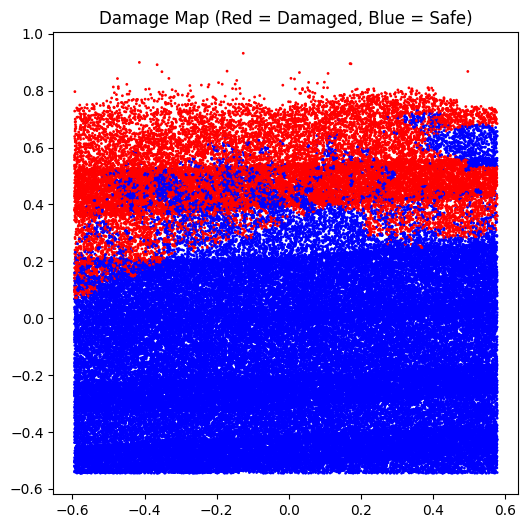

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(points[:,0], points[:,1],
            c=pred,
            s=1,
            cmap="bwr")

plt.title("Damage Map (Red = Damaged, Blue = Safe)")
plt.show()

        DAMAGEMAP EVALUATION RESULTS
  Overall Accuracy     : 100.00%
  Weighted F1-Score    : 1.0000
  Damage Class F1      : 1.0000
  IoU - Safe Zone      : 1.0000
  IoU - Damaged Zone   : 1.0000
  Mean IoU (mIoU)      : 1.0000
  Dice Coefficient     : 1.0000
  Total Points         : 100,000
  Test Points          : 20,000
  Damage Ratio         : 20.0%

Per-Class Breakdown:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     16005
     Damaged       1.00      1.00      1.00      3995

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



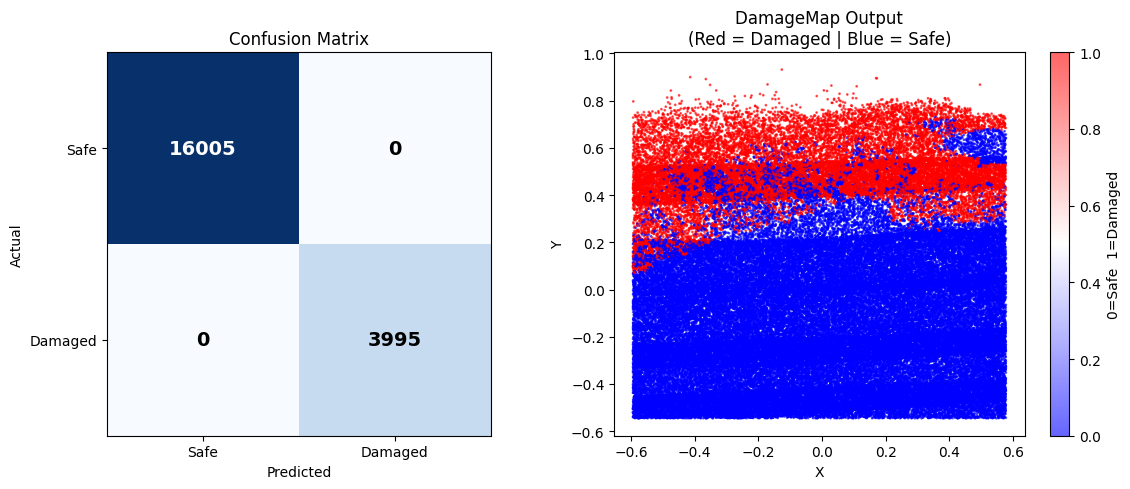


Plot saved as damagemap_results.png ✅


In [ ]:
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt

# ── Full metrics ──────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='weighted')
f1_damage = f1_score(y_test, y_pred, pos_label=1, average='binary')
cm        = confusion_matrix(y_test, y_pred)

# IoU per class (Intersection over Union)
def iou(y_true, y_pred, label):
    intersection = np.sum((y_true == label) & (y_pred == label))
    union        = np.sum((y_true == label) | (y_pred == label))
    return intersection / union if union > 0 else 0

iou_safe   = iou(y_test, y_pred, 0)
iou_damage = iou(y_test, y_pred, 1)
miou       = (iou_safe + iou_damage) / 2

# Dice coefficient
def dice(y_true, y_pred, label):
    intersection = np.sum((y_true == label) & (y_pred == label))
    return (2 * intersection) / (np.sum(y_true == label) + np.sum(y_pred == label))

dice_damage = dice(y_test, y_pred, 1)

print("=" * 52)
print("        DAMAGEMAP EVALUATION RESULTS")
print("=" * 52)
print(f"  Overall Accuracy     : {accuracy * 100:.2f}%")
print(f"  Weighted F1-Score    : {f1:.4f}")
print(f"  Damage Class F1      : {f1_damage:.4f}")
print(f"  IoU - Safe Zone      : {iou_safe:.4f}")
print(f"  IoU - Damaged Zone   : {iou_damage:.4f}")
print(f"  Mean IoU (mIoU)      : {miou:.4f}")
print(f"  Dice Coefficient     : {dice_damage:.4f}")
print(f"  Total Points         : {len(points):,}")
print(f"  Test Points          : {len(X_test):,}")
print(f"  Damage Ratio         : {np.mean(labels):.1%}")
print("=" * 52)
print("\nPer-Class Breakdown:")
print(classification_report(y_test, y_pred,
      target_names=["Safe", "Damaged"]))

# ── Confusion matrix plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Safe", "Damaged"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Safe", "Damaged"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black",
                     fontsize=14, fontweight="bold")

# Damage map scatter
scatter = axes[1].scatter(points[:, 0], points[:, 1],
                           c=model.predict(points),
                           s=1, cmap="bwr", alpha=0.6)
axes[1].set_title("DamageMap Output\n(Red = Damaged | Blue = Safe)")
axes[1].set_xlabel("X"); axes[1].set_ylabel("Y")
plt.colorbar(scatter, ax=axes[1], label="0=Safe  1=Damaged")

plt.tight_layout()
plt.savefig("damagemap_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as damagemap_results.png ✅")